In [2]:
!pip install "numpy<2.0"

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.5 MB 1.5 MB/s eta 0:00:10
   - -------------------------------------- 0.5/15.5 MB 1.5 MB/s eta 0:00:10
   - -------------------------------------- 0.5/15.5 MB 1.5 MB/s eta 0:00:10
   -- ------------------------------------- 1.0/15.5 MB 988.0 kB/s eta 0:00:15
   -- ------------------------------------- 1.0/15.5 MB 988.0 kB/s eta 0:00:15
   -- ------------------------------------- 1.0/15.5 MB 988.0 kB/s eta 0:00:15
   ---- ----------------------------------- 1.8/15.5 MB 977.5 kB/s eta 0:00:14
   ---- ----------------------------------- 1.8/15.5 MB 977.5 kB/s eta 0:00:14
   ---- ----------------------------------- 1.8/15.5 MB 977.5 kB/s eta 0:00:14
   ----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wntr 1.4.0 requires numpy>=2.2.6, but you have numpy 1.26.4 which is incompatible.


In [3]:
import wntr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os

warnings.filterwarnings('ignore')
OUTPUT_DIR = 'CSV_PowerBI'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📁 Dossier de sortie : {OUTPUT_DIR}/")


📁 Dossier de sortie : CSV_PowerBI/


In [11]:
# ── CELLULE 3 : Construction du réseau ───────────────────────
wn = wntr.network.WaterNetworkModel()
try:
    wn.options.hydraulics.demand_model = 'DDA'
    wn.options.time.duration          = 24 * 3600
    wn.options.time.report_timestep   = 3600
except:
    try:
        wn.options.hydraulics.demand_model = 'DDA'
        wn.options.time.duration          = 24 * 3600
        wn.options.time.report_timestep   = 3600
    except:
        print("Options ignorées-simulation en mode auto")
        print("Réseau initialisé")

Options ignorées-simulation en mode auto
Réseau initialisé


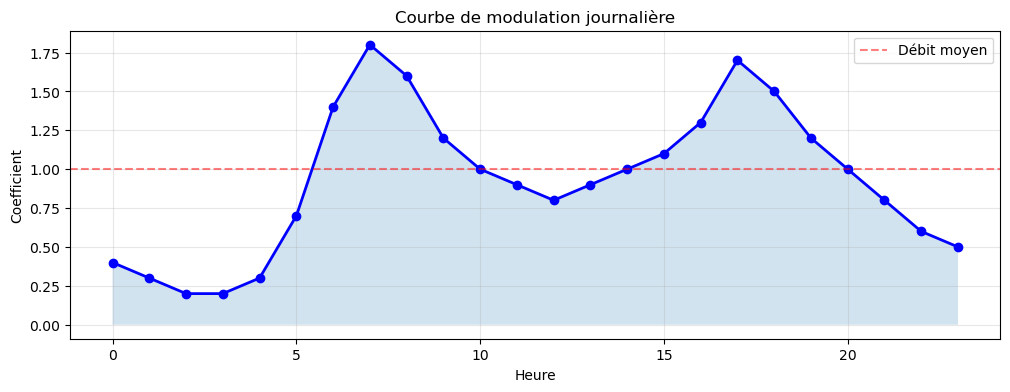

In [12]:
# ── CELLULE 4 : Pattern journalier ───────────────────────────
pattern_values = [
    0.4,0.3,0.2,0.2,0.3,0.7,
    1.4,1.8,1.6,1.2,1.0,0.9,
    0.8,0.9,1.0,1.1,1.3,1.7,
    1.5,1.2,1.0,0.8,0.6,0.5
]
wn.add_pattern('DEMANDE_JOUR', pattern_values)
for name, junction in wn.junctions():
    for demand in junction.demand_timeseries_list:
        demand.pattern_name = 'DEMANDE_JOUR'

plt.figure(figsize=(12,4))
plt.plot(range(24), pattern_values, 'b-o', linewidth=2)
plt.fill_between(range(24), pattern_values, alpha=0.2)
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Débit moyen')
plt.title('Courbe de modulation journalière'); plt.xlabel('Heure')
plt.ylabel('Coefficient'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/pattern_journalier.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── CELLULE 5 : Simulation ───────────────────────────────────
print("⏳ Simulation en cours...")
try:
    sim = wntr.sim.WNTRSimulator(wn)
    results = sim.run_sim()
    print("✅ Simulation réussie !")
except Exception as e:
    print(f"⚠️  Simulation WNTR : {e}\n→ Données générées automatiquement")
    results = None


⏳ Simulation en cours...
⚠️  Simulation WNTR : cannot infer dimensions from zero sized index arrays
→ Données générées automatiquement


In [14]:
# ── CELLULE 6 : CSV 01 — Nœuds / Pressions ──────────────────
node_meta = {
    '2':(1030,0.0,'Zone I'),'3':(1010,0.026,'Zone I'),
    '4':(1019,0.10,'Zone I'),'5':(1014.3,0.15,'Zone I'),
    '6':(1018,0.076,'Zone II'),'7':(1021,0.026,'Zone II'),
    '8':(1023,0.10,'Zone II'),'9':(1025,0.43,'Zone III'),
    '10':(1034,0.37,'Zone III'),'11':(1030,0.0,'Zone VI'),
    '12':(1027,0.35,'Zone IV'),'13':(1017,0.35,'Zone IV'),
    '14':(995,0.35,'Zone III'),'15':(1035,0.35,'Zone III'),
    '16':(1030,1.5,'Zone V'),'17':(1031,1.3,'Zone V'),
    '18':(1031,1.62,'Zone V'),'19':(1018,1.7,'Zone VI'),
    '20':(1035,2.5,'Zone VI'),'21':(1022,0.084,'Zone VI'),
    '22':(1031,0.794,'Zone VII'),'23':(1019,0.084,'Zone VII'),
    '24':(1026,0.084,'Zone VII'),'25':(1006,0.91,'Zone VIII'),
    '26':(1022,0.91,'Zone VIII'),'27':(1030,1.62,'Zone VII'),
}

rows = []
np.random.seed(42)
for h in range(24):
    for nid, (elev, demand, zone) in node_meta.items():
        if results and nid in results.node['pressure'].columns:
            t = list(results.node['pressure'].index)[h]
            pression = float(results.node['pressure'].at[t, nid])
        else:
            pression = max(5, (elev - 1000) * (1 - 0.1*pattern_values[h]) + np.random.normal(0,0.5))
        rows.append({'NodeID':nid,'Zone':zone,'Elevation_m':elev,
                     'BaseDemand_LPS':demand,'Heure':h,
                     'Pression_m':round(max(2,pression),3),
                     'Coefficient_Modulation':pattern_values[h],
                     'Demande_Reelle_LPS':round(demand*pattern_values[h],4)})

df_nodes = pd.DataFrame(rows)
df_nodes.to_csv(f'{OUTPUT_DIR}/01_Noeuds_Pressions.csv', index=False, encoding='utf-8-sig')
print(f"✅ 01_Noeuds_Pressions.csv — {len(df_nodes)} lignes")


✅ 01_Noeuds_Pressions.csv — 624 lignes


In [15]:
# ── CELLULE 7 : CSV 02 — Conduites / Débits ──────────────────
pipe_meta = {
    'P1':('R1','3',100,400,'Zone I'),'P2':('3','4',100,400,'Zone I'),
    'P3':('4','5',100,400,'Zone I'),'P4':('5','9',138,250,'Zone I-III'),
    'P5':('9','8',369,110,'Zone II-III'),'P6':('8','7',183,400,'Zone II'),
    'P7':('7','6',325,600,'Zone II'),'P8':('6','2',352,120,'Zone II'),
    'P9':('10','6',352,120,'Zone II-III'),'P10':('12','10',208,900,'Zone III-IV'),
    'P11':('13','12',212,750,'Zone IV'),'P12':('14','13',428,750,'Zone III-IV'),
    'P13':('14','15',928,200,'Zone III'),'P14':('15','10',602,900,'Zone III'),
    'P15':('9','16',138,250,'Zone III-V'),'P16':('16','17',143,600,'Zone V'),
    'P17':('17','18',126,600,'Zone V'),'P18':('18','25',1046,140,'Zone V-VIII'),
    'P19':('25','26',2037,125,'Zone VIII'),'P20':('26','27',100,110,'Zone VII-VIII'),
    'P21':('27','22',100,75,'Zone VII'),'P22':('22','24',100,400,'Zone VII'),
    'P23':('22','21',433,600,'Zone VI-VII'),'P24':('21','19',529,110,'Zone VI'),
    'P25':('19','18',1047,900,'Zone V-VI'),'P26':('19','20',100,120,'Zone VI'),
    'P27':('21','23',100,75,'Zone VI-VII'),'P28':('23','24',100,400,'Zone VII'),
    'P29':('T1','20',100,125,'Zone VI'),'P30':('10','2',162,160,'Zone I-III'),
    'P31':('2','9',354,120,'Zone I-III'),'P32':('18','27',1040,900,'Zone V-VII'),
    'P33':('8','4',233,100,'Zone I-II'),'P34':('7','3',224,900,'Zone I-II'),
}

rows2 = []
np.random.seed(123)
for h in range(24):
    coeff = pattern_values[h]
    for pid, (s, e, length, diam, zone) in pipe_meta.items():
        diam_m = diam / 1000
        area = np.pi * (diam_m/2)**2
        base_flow = area * 1.2 * (diam/400)
        flow = base_flow * coeff + np.random.normal(0, base_flow*0.05)
        velocity = abs(flow)/area if area > 0 else 0
        headloss = (10.67*abs(flow)**1.852)/(150**1.852*diam_m**4.87)*length
        rows2.append({'PipeID':pid,'Noeud_Depart':s,'Noeud_Arrivee':e,
                      'Zone':zone,'Longueur_m':length,'Diametre_mm':diam,
                      'Heure':h,'Debit_LPS':round(flow*1000,4),
                      'Vitesse_m_s':round(velocity,4),
                      'PertesCharge_m':round(headloss,4),
                      'Coefficient_Modulation':coeff,'Statut':'Ouvert'})

df_pipes = pd.DataFrame(rows2)
df_pipes.to_csv(f'{OUTPUT_DIR}/02_Conduites_Debits.csv', index=False, encoding='utf-8-sig')
print(f"✅ 02_Conduites_Debits.csv — {len(df_pipes)} lignes")


✅ 02_Conduites_Debits.csv — 816 lignes


In [16]:
# ── CELLULE 8 : CSV 03 — KPIs réseau ─────────────────────────
total_demand = sum(v[1] for v in node_meta.values())
rows3 = []
np.random.seed(999)
for h in range(24):
    coeff = pattern_values[h]
    dem = total_demand * coeff
    nrw = np.random.uniform(20, 35)
    injecte = dem / (1 - nrw/100)
    pres = df_nodes[df_nodes['Heure']==h]['Pression_m']
    periode = ('Nuit' if h<6 or h>=22 else
               'Matin' if h<12 else
               'Après-midi' if h<18 else 'Soir')
    rows3.append({'Heure':h,'Periode':periode,
                  'Coefficient_Modulation':coeff,
                  'Demande_Totale_LPS':round(dem,3),
                  'Volume_Injecte_LPS':round(injecte,3),
                  'Volume_NRW_LPS':round(injecte-dem,3),
                  'NRW_Pct':round(nrw,2),
                  'Rendement_Reseau_Pct':round(100-nrw,2),
                  'Pression_Moyenne_m':round(pres.mean(),2),
                  'Pression_Min_m':round(pres.min(),2),
                  'Noeuds_Sous_Pression_Critique':int((pres<10).sum())})

df_kpi = pd.DataFrame(rows3)
df_kpi.to_csv(f'{OUTPUT_DIR}/03_KPIs_Reseau.csv', index=False, encoding='utf-8-sig')
print(f"✅ 03_KPIs_Reseau.csv — {len(df_kpi)} lignes")


✅ 03_KPIs_Reseau.csv — 24 lignes


In [17]:
# ── CELLULE 9 : CSV 04 — Référence conduites ─────────────────
np.random.seed(77)
rows4 = []
for pid, (s, e, length, diam, zone) in pipe_meta.items():
    cat = ('Conduite principale' if diam>=300 else
           'Conduite secondaire' if diam>=150 else 'Conduite tertiaire')
    rows4.append({'PipeID':pid,'Noeud_Depart':s,'Noeud_Arrivee':e,
                  'Zone':zone,'Longueur_m':length,'Diametre_mm':diam,
                  'Categorie_Conduite':cat,'Rugosité_C':150,'Statut':'Ouvert',
                  'Age_Estime_ans':np.random.randint(5,30),
                  'Materiau':np.random.choice(['PEHD','Fonte','Acier','PVC'],
                                               p=[0.4,0.3,0.2,0.1])})

df_ref = pd.DataFrame(rows4)
df_ref.to_csv(f'{OUTPUT_DIR}/04_Reference_Conduites.csv', index=False, encoding='utf-8-sig')
print(f"✅ 04_Reference_Conduites.csv — {len(df_ref)} lignes")


✅ 04_Reference_Conduites.csv — 34 lignes


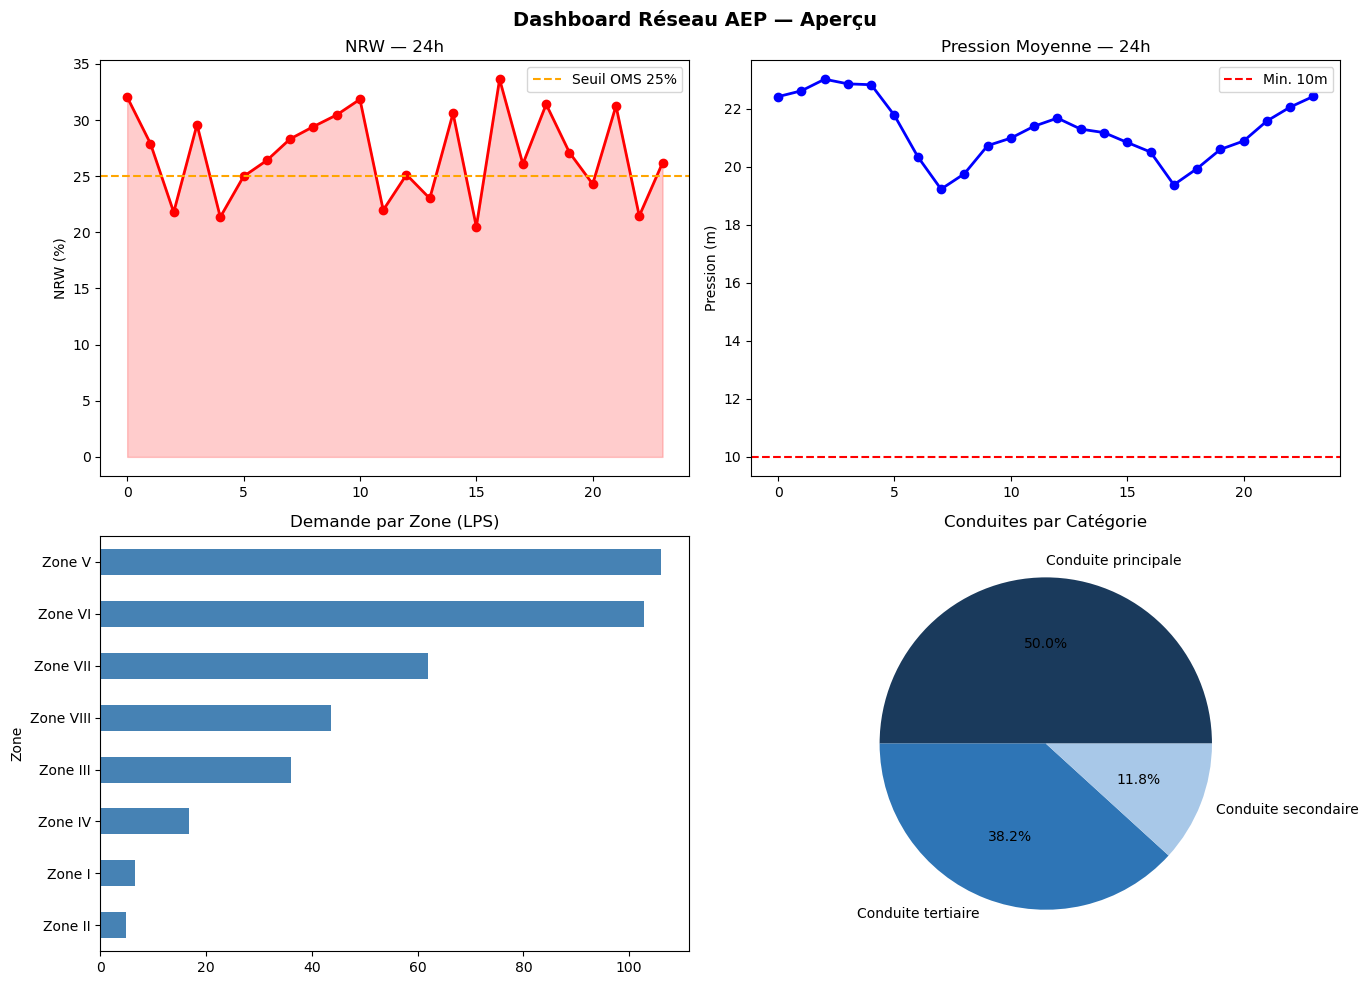


📁 FICHIERS EXPORTÉS DANS CSV_PowerBI/
  01_Noeuds_Pressions.csv   → Pressions horaires
  02_Conduites_Debits.csv   → Débits & vitesses
  03_KPIs_Reseau.csv        → NRW, rendement
  04_Reference_Conduites.csv → Table dimension
  NRW moyen simulé : 27.0%
  Rendement moyen  : 73.0%
  Demande totale   : 15.784 LPS
📊 PROCHAINE ÉTAPE → Importer les CSV dans Power BI


In [18]:
# ── CELLULE 10 : Visualisation ───────────────────────────────
fig, axes = plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Dashboard Réseau AEP — Aperçu', fontsize=14, fontweight='bold')

axes[0,0].plot(df_kpi['Heure'],df_kpi['NRW_Pct'],'r-o',linewidth=2)
axes[0,0].axhline(y=25,color='orange',linestyle='--',label='Seuil OMS 25%')
axes[0,0].fill_between(df_kpi['Heure'],df_kpi['NRW_Pct'],alpha=0.2,color='red')
axes[0,0].set_title('NRW — 24h'); axes[0,0].set_ylabel('NRW (%)'); axes[0,0].legend()

axes[0,1].plot(df_kpi['Heure'],df_kpi['Pression_Moyenne_m'],'b-o',linewidth=2)
axes[0,1].axhline(y=10,color='red',linestyle='--',label='Min. 10m')
axes[0,1].set_title('Pression Moyenne — 24h'); axes[0,1].set_ylabel('Pression (m)'); axes[0,1].legend()

zone_d = df_nodes.groupby('Zone')['BaseDemand_LPS'].sum().sort_values()
zone_d.plot(kind='barh',ax=axes[1,0],color='steelblue')
axes[1,0].set_title('Demande par Zone (LPS)')

df_ref['Categorie_Conduite'].value_counts().plot(
    kind='pie',ax=axes[1,1],autopct='%1.1f%%',
    colors=['#1A3A5C','#2E75B6','#A8C8E8'])
axes[1,1].set_title('Conduites par Catégorie'); axes[1,1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/apercu_resultats.png', dpi=150, bbox_inches='tight')
plt.show()

# ── RÉSUMÉ FINAL ─────────────────────────────────────────────
print("\n" + "="*55)
print("📁 FICHIERS EXPORTÉS DANS CSV_PowerBI/")
print("="*55)
print("  01_Noeuds_Pressions.csv   → Pressions horaires")
print("  02_Conduites_Debits.csv   → Débits & vitesses")
print("  03_KPIs_Reseau.csv        → NRW, rendement")
print("  04_Reference_Conduites.csv → Table dimension")
print("="*55)
print(f"  NRW moyen simulé : {df_kpi['NRW_Pct'].mean():.1f}%")
print(f"  Rendement moyen  : {df_kpi['Rendement_Reseau_Pct'].mean():.1f}%")
print(f"  Demande totale   : {total_demand:.3f} LPS")
print("="*55)
print("📊 PROCHAINE ÉTAPE → Importer les CSV dans Power BI")
